# Analyse du Dataset de Véhicules
**Pipeline complet : Nettoyage → EDA → Feature Engineering → Preprocessing**

## 1. Import des packages

In [44]:
# Import des packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print(' Packages importés avec succès')

 Packages importés avec succès


## 2. Importation de la base de données

In [47]:
# Importation
df = pd.read_csv(r"C:\Users\used_cars_data_shorter.csv")

print(f'Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions : 1,814,329 lignes × 43 colonnes


,vin,back_legroom,bed_length,body_type,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,engine_type,fleet,franchise_dealer,franchise_make,front_legroom,fuel_tank_volume,fuel_type,height,highway_fuel_economy,horsepower,is_new,is_oemcpo,length,listed_date,listing_color,listing_id,major_options,make_name,maximum_seating,mileage,model_name,power,price,sp_name,torque,transmission,transmission_display,trimId,trim_name,wheel_system,wheel_system_display,wheelbase,width,year
0,SALCJ2FX1LH858117,38.1 in,NaN,SUV / Crossover,NaN,NaN,207,I4,2000.0,I4,NaN,True,Land Rover,39.1 in,17.7 gal,Gasoline,68 in,NaN,246.0,True,NaN,181 in,2020-02-15,BLACK,265946296,['Adaptive Cruise Control'],Land Rover,7 seats,8.0,Discovery Sport,"246 hp @ 5,500 RPM",46500.0,Land Rover San Juan,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
1,SALRR2RV0L2433391,37.6 in,NaN,SUV / Crossover,NaN,NaN,196,V6,3000.0,V6,NaN,True,Land Rover,39 in,23.5 gal,Gasoline,73 in,NaN,340.0,True,NaN,195.1 in,2020-02-26,GRAY,266911050,NaN,Land Rover,7 seats,11.0,Discovery,"340 hp @ 6,500 RPM",67430.0,Land Rover San Juan,"332 lb-ft @ 3,500 RPM",A,8-Speed Automatic Overdrive,t86074,V6 HSE AWD,AWD,All-Wheel Drive,115 in,87.4 in,2020
2,SALCJ2FXXLH862327,38.1 in,NaN,SUV / Crossover,NaN,NaN,137,I4,2000.0,I4,NaN,True,Land Rover,39.1 in,17.7 gal,Gasoline,68 in,NaN,246.0,True,NaN,181 in,2020-04-25,BLACK,270957414,['Adaptive Cruise Control'],Land Rover,7 seats,7.0,Discovery Sport,"246 hp @ 5,500 RPM",48880.0,Land Rover San Juan,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
3,SALYK2EX1LA261711,37.1 in,NaN,SUV / Crossover,NaN,NaN,242,I4,2000.0,I4,False,True,Land Rover,40.2 in,16.6 gal,Gasoline,66.3 in,NaN,247.0,True,NaN,188.9 in,2020-01-11,UNKNOWN,262940541,"['Leather Seats', 'Sunroof/Moonroof', 'Navigat...",Land Rover,5 seats,12.0,Range Rover Velar,"247 hp @ 5,500 RPM",66903.0,Land Rover San Juan,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020
4,SALYK2EX5LA275434,37.1 in,NaN,SUV / Crossover,NaN,NaN,70,I4,2000.0,I4,NaN,True,Land Rover,40.2 in,16.6 gal,Gasoline,66.3 in,NaN,247.0,True,NaN,188.9 in,2020-07-01,WHITE,275458784,['Adaptive Cruise Control'],Land Rover,5 seats,11.0,Range Rover Velar,"247 hp @ 5,500 RPM",68520.0,Land Rover San Juan,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020


In [ ]:
# type des variables 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1814329 entries, 0 to 1814328
Data columns (total 43 columns):
 #   Column                Dtype  
---  ------                -----  
 0   vin                   str    
 1   back_legroom          str    
 2   bed_length            str    
 3   body_type             str    
 4   city_fuel_economy     float64
 5   combine_fuel_economy  float64
 6   daysonmarket          int64  
 7   engine_cylinders      str    
 8   engine_displacement   float64
 9   engine_type           str    
 10  fleet                 object 
 11  franchise_dealer      bool   
 12  franchise_make        str    
 13  front_legroom         str    
 14  fuel_tank_volume      str    
 15  fuel_type             str    
 16  height                str    
 17  highway_fuel_economy  float64
 18  horsepower            float64
 19  is_new                bool   
 20  is_oemcpo             object 
 21  length                str    
 22  listed_date           str    
 23  listing_color     

In [ ]:
#Statistiques élémentaires
df.describe()

,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_displacement,highway_fuel_economy,horsepower,listing_id,mileage,price,year
count,1.541391e+06,0.0,1.814329e+06,1.708225e+06,1.541391e+06,1.708225e+06,1.814329e+06,1.722152e+06,1.814329e+06,1.814329e+06
mean,2.336320e+01,NaN,7.679137e+01,2.845629e+03,2.996273e+01,2.462581e+02,2.755232e+08,1.508637e+04,3.326311e+04,2.018875e+03
std,9.428403e+00,NaN,8.561693e+01,1.301749e+03,8.058095e+00,9.084264e+01,6.593205e+06,2.907274e+04,1.898445e+04,3.130724e+00
min,8.000000e+00,NaN,0.000000e+00,7.000000e+02,1.100000e+01,5.500000e+01,2.518374e+08,0.000000e+00,2.990000e+02,1.915000e+03
25%,1.800000e+01,NaN,1.800000e+01,2.000000e+03,2.500000e+01,1.740000e+02,2.736020e+08,5.000000e+00,2.199000e+04,2.018000e+03
50%,2.200000e+01,NaN,4.100000e+01,2.500000e+03,2.900000e+01,2.400000e+02,2.780568e+08,1.200000e+01,2.913400e+04,2.020000e+03
75%,2.600000e+01,NaN,9.400000e+01,3.500000e+03,3.300000e+01,3.000000e+02,2.801670e+08,2.218100e+04,4.096900e+04,2.020000e+03
max,1.270000e+02,NaN,3.640000e+02,8.400000e+03,1.270000e+02,9.490000e+02,2.820222e+08,1.225238e+06,2.749950e+06,2.021000e+03


## 3. Nettoyage des données

### 3.1 Valeurs manquantes

In [5]:
# Calcul du pourcentage de valeurs manquantes
missing_percent = df.isna().mean() * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

print(f'{len(missing_df)} colonnes avec des valeurs manquantes :\n')
print(missing_df.round(2).to_string())

31 colonnes avec des valeurs manquantes :

combine_fuel_economy    100.00
is_oemcpo                94.98
bed_length               85.91
fleet                    62.68
torque                   19.02
power                    17.92
highway_fuel_economy     15.04
city_fuel_economy        15.04
franchise_make            8.86
major_options             6.12
horsepower                5.85
engine_displacement       5.85
height                    5.11
back_legroom              5.11
fuel_tank_volume          5.11
width                     5.11
length                    5.11
maximum_seating           5.11
wheelbase                 5.11
front_legroom             5.11
mileage                   5.08
wheel_system              4.93
wheel_system_display      4.93
trim_name                 3.79
trimId                    3.79
engine_cylinders          3.17
engine_type               3.17
fuel_type                 2.42
transmission              1.93
transmission_display      1.93
body_type                 0

La plupart des variables ont des valeurs manquantes, seulement 4 ont plus de 50% de valeurs manquantes que nous avons supprimés. 

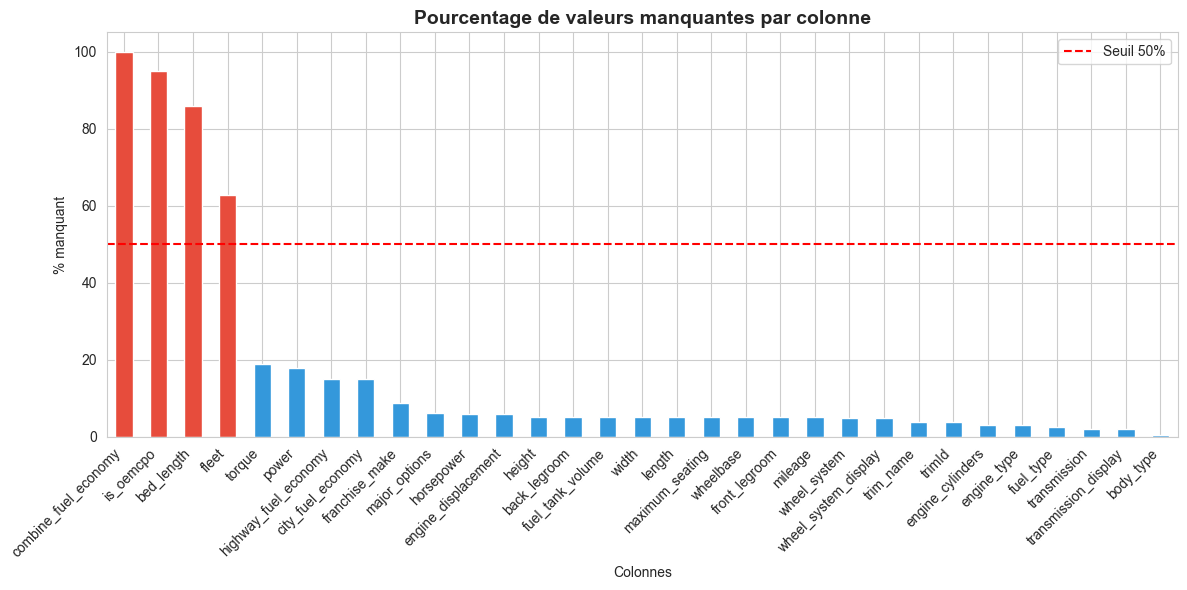

In [6]:
# Visualisation
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if v > 50 else '#3498db' for v in missing_df.values]
missing_df.plot(kind='bar', color=colors, edgecolor='white')
plt.axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Seuil 50%')
plt.title('Pourcentage de valeurs manquantes par colonne', fontsize=14, fontweight='bold')
plt.xlabel('Colonnes')
plt.ylabel('% manquant')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Règle de traiatement des valeurs manquantes
# - Supprimer les variables de plus de 50% de manquants 
# - Amputer les autres ayant des manquants par la médiane si quantitative et le mode si qualitative (La médiane car elle est une statistique robuste)

In [7]:
# Suppression des colonnes avec > 50% de valeurs manquantes
cols_to_drop = missing_percent[missing_percent > 50].index
print(f'Colonnes supprimées (> 50% manquant) : {list(cols_to_drop)}')
df = df.drop(columns=cols_to_drop)

# Séparer variables quantitatives et qualitatives
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Imputation médiane pour les variables quantitatives
for col in num_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Imputation mode pour les variables qualitatives
for col in cat_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f'\nValeurs manquantes restantes : {df.isna().sum().sum()}')
print(f'Dimensions après nettoyage : {df.shape}')

Colonnes supprimées (> 50% manquant) : ['bed_length', 'combine_fuel_economy', 'fleet', 'is_oemcpo']

Valeurs manquantes restantes : 0
Dimensions après nettoyage : (1814329, 39)


In [ ]:
# Notre base de donnée passe de 1814329 lignes 43 colonnes à  1814329 lignes 39 colonnes. 

### 3.2 Nettoyage des unités (colonnes avec « in », « gal »...)

In [ ]:
# Certaines colonnes avait des valeurs numériques et des chiffres au sein des cellules, ce qui impacte le 
# type de la variable. Ce pourquoi nous avons fait les deux traitements suivants

In [ ]:
# Fonction pour extraire la valeur numérique d'une chaîne avec unité
def extract_numeric(val):
    if pd.isna(val):
        return np.nan
    match = re.search(r'[\d\.]+', str(val))
    return float(match.group()) if match else np.nan

# Colonnes à nettoyer (contiennent des unités textuelles)
unit_cols = ['back_legroom', 'front_legroom', 'wheelbase', 'width',
             'length', 'height', 'fuel_tank_volume']
unit_cols = [c for c in unit_cols if c in df.columns]

for col in unit_cols:
    df[col] = df[col].apply(extract_numeric)

print(' Unités nettoyées pour :', unit_cols)
df[unit_cols].head(3)

 Unités nettoyées pour : ['back_legroom', 'front_legroom', 'wheelbase', 'width', 'length', 'height', 'fuel_tank_volume']


,back_legroom,front_legroom,wheelbase,width,length,height,fuel_tank_volume
0,38.1,39.1,107.9,85.6,181.0,68.0,17.7
1,37.6,39.0,115.0,87.4,195.1,73.0,23.5
2,38.1,39.1,107.9,85.6,181.0,68.0,17.7


### 3.3 Extraction de `power` et `torque`

In [ ]:
# Extraire la valeur numérique de power : "246 hp @ 5,500 RPM" → 246
if 'power' in df.columns:
    df['horsepower_val'] = df['power'].apply(lambda x: extract_numeric(str(x).split('hp')[0]) if pd.notna(x) else np.nan)

# Extraire la valeur numérique de torque : "269 lb-ft @ 1,400 RPM" → 269
if 'torque' in df.columns:
    df['torque_val'] = df['torque'].apply(lambda x: extract_numeric(str(x).split('lb')[0]) if pd.notna(x) else np.nan)

print(' Colonnes power et torque extraites')
df[['power', 'horsepower_val', 'torque', 'torque_val']].head(3)

 Colonnes power et torque extraites


,power,horsepower_val,torque,torque_val
0,"246 hp @ 5,500 RPM",246.0,"269 lb-ft @ 1,400 RPM",269.0
1,"340 hp @ 6,500 RPM",340.0,"332 lb-ft @ 3,500 RPM",332.0
2,"246 hp @ 5,500 RPM",246.0,"269 lb-ft @ 1,400 RPM",269.0


In [ ]:
# Ici par exemple, on a crée la colonne des chevaux du véhicule en faisant une extraction des valeurs dans la colonne power à la base pour
# créer la colonne horsepower qui est ici numérique. 

### 3.4 Traitement de `listed_date`

In [ ]:
if 'listed_date' in df.columns:
    df['listed_date'] = pd.to_datetime(df['listed_date'], errors='coerce')
    df['listed_month'] = df['listed_date'].dt.month
    df['listed_year']  = df['listed_date'].dt.year
    df['listed_dayofweek'] = df['listed_date'].dt.dayofweek
    print(' listed_date convertie et décomposée')
    df[['listed_date', 'listed_year', 'listed_month', 'listed_dayofweek']].head(3)

 listed_date convertie et décomposée


In [ ]:
# On a converti la variable listed_date en format date puis extrait le mois, l’année et le jour de la semaine comme nouvelles variables.

### 3.5 Doublons

In [42]:
n_dup = df.duplicated().sum()
print(f'Doublons trouvés : {n_dup}')
if n_dup > 0:
    df = df.drop_duplicates()
    print(f' Doublons supprimés. Nouvelles dimensions : {df.shape}')

Doublons trouvés : 55746
 Doublons supprimés. Nouvelles dimensions : (1758563, 56)


On a détecté les doublons dans la base de données puis supprimé ceux existants afin de conserver uniquement les observations uniques.

## 4. EDA — Analyse Exploratoire

### 4.1 Distribution de la variable cible : `price`

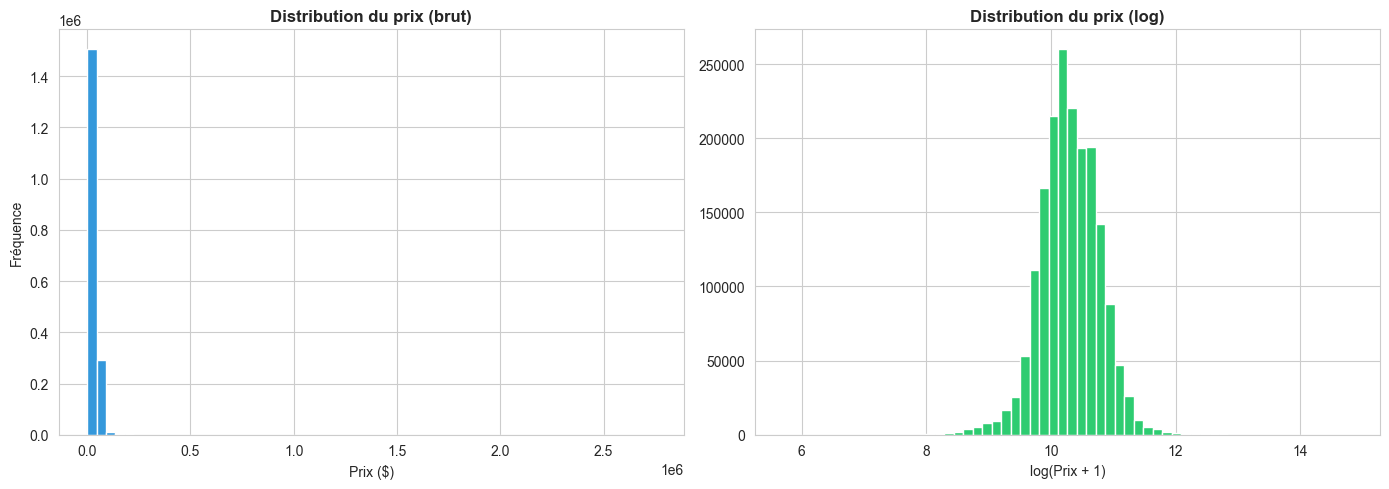

count    1814309.00
mean       33263.17
std        18984.52
min          299.00
25%        21990.00
50%        29134.00
75%        40969.00
max      2749950.00
Name: price, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution brute
axes[0].hist(df['price'].dropna(), bins=60, color='#3498db', edgecolor='white')
axes[0].set_title('Distribution du prix (brut)', fontweight='bold')
axes[0].set_xlabel('Prix ($)')
axes[0].set_ylabel('Fréquence')

# Distribution log
axes[1].hist(np.log1p(df['price'].dropna()), bins=60, color='#2ecc71', edgecolor='white')
axes[1].set_title('Distribution du prix (log)', fontweight='bold')
axes[1].set_xlabel('log(Prix + 1)')

plt.tight_layout()
plt.show()

print(df['price'].describe().round(2))

La distribution du prix brut est fortement asymétrique à droite, tandis que la transformation logarithmique rend la distribution beaucoup plus symétrique et proche d’une distribution normale. 50% des véhicules ont un prix inéfrieur à 29134 unité monétaire (médiane). 

### 4.2 Variables catégorielles clés

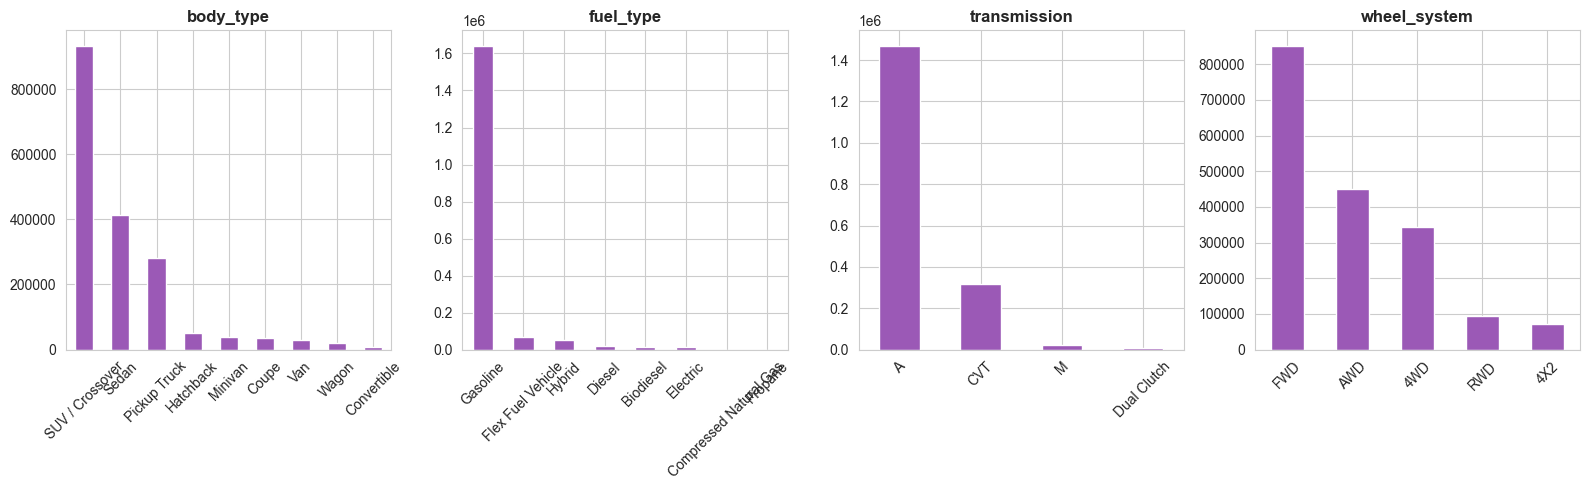

In [ ]:
# Repartion selon les modalités des variables catégorielles 
cat_features = ['body_type', 'fuel_type', 'transmission', 'wheel_system']
cat_features = [c for c in cat_features if c in df.columns]

fig, axes = plt.subplots(1, len(cat_features), figsize=(16, 5))
if len(cat_features) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_features):
    counts = df[col].value_counts().head(10)
    counts.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='white')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Les graphiques montrent que les SUV/Crossover dominent largement les types de carrosserie, tandis que l’essence est de loin le type de carburant le plus fréquent. On observe également une forte prédominance des transmissions automatiques et des véhicules à traction avant (FWD) dans l’échantillon.

### 4.3 Variables numériques — boxplots

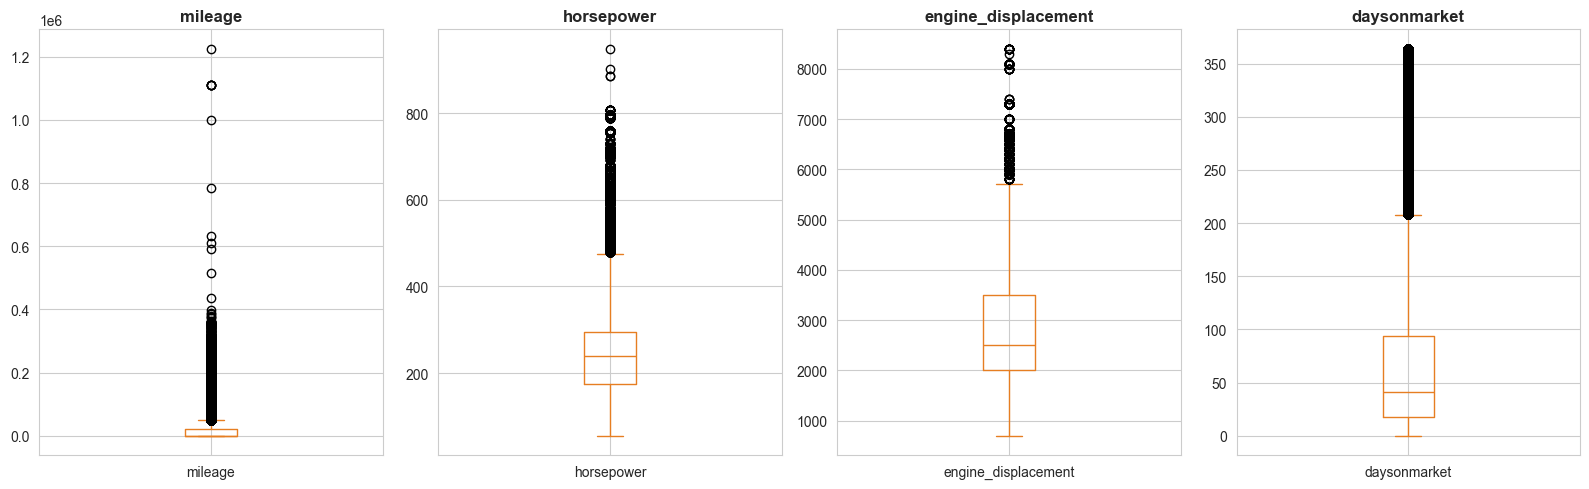

In [ ]:
# Visualisation de la distribution des variables quantitatives 
num_features = ['mileage', 'horsepower', 'engine_displacement', 'daysonmarket']
num_features = [c for c in num_features if c in df.columns]

fig, axes = plt.subplots(1, len(num_features), figsize=(16, 5))
if len(num_features) == 1:
    axes = [axes]

for ax, col in zip(axes, num_features):
    df[col].dropna().plot(kind='box', ax=ax, color='#e67e22')
    ax.set_title(f'{col}', fontweight='bold')

plt.tight_layout()
plt.show()

Les boxplots montrent la présence de nombreuses valeurs extrêmes (outliers), notamment pour le mileage, la puissance et la cylindrée du moteur.
La variable daysonmarket présente également une dispersion importante, indiquant que certains véhicules restent beaucoup plus longtemps en vente que la majorité.

### 4.4 Matrice de corrélation

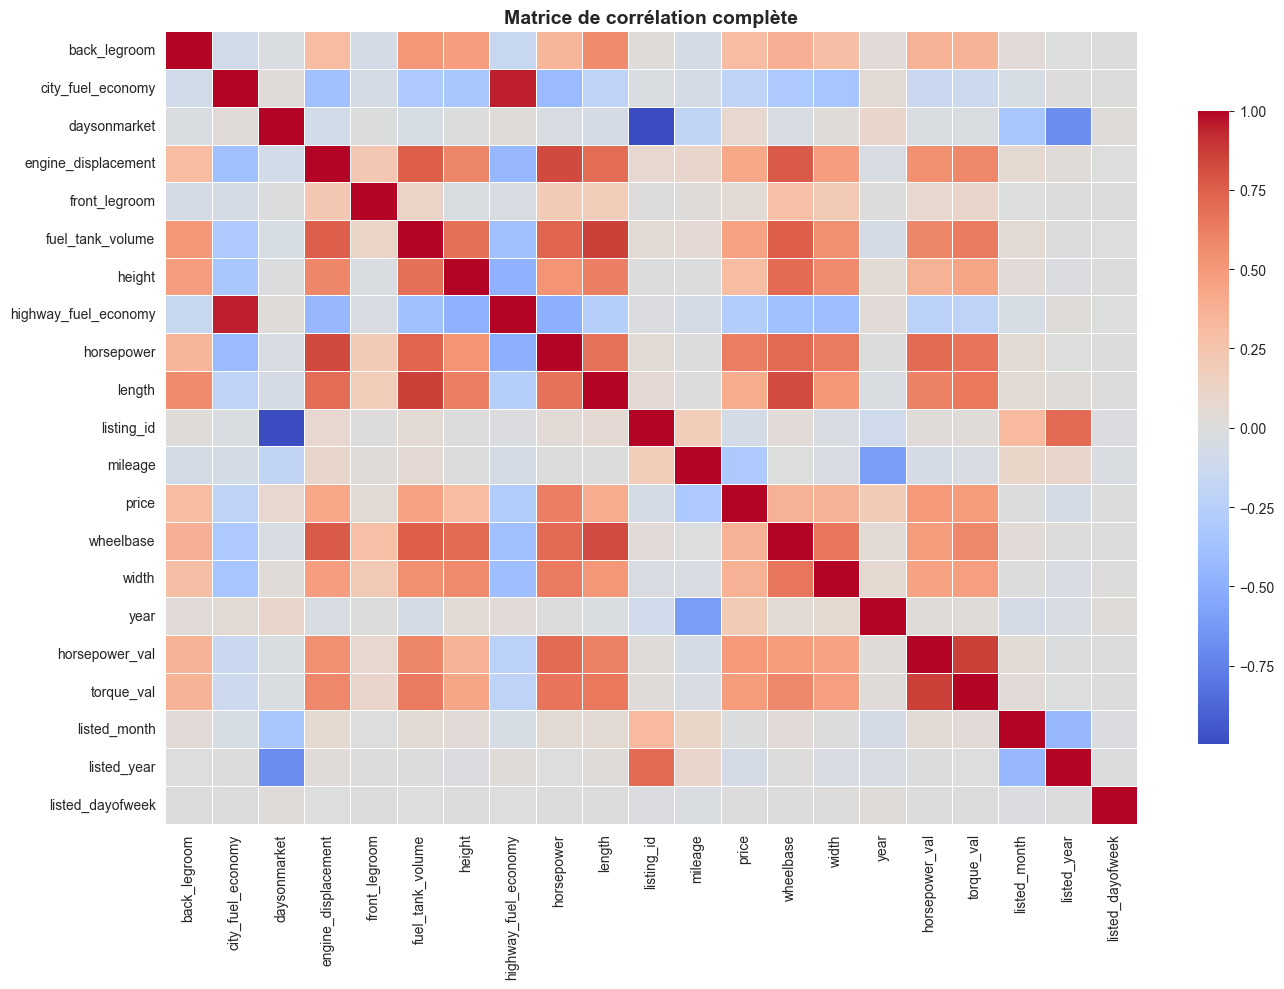

In [ ]:
# Répresentation de la matrice de corrélation 
corr_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matrice de corrélation complète', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

La matrice montre que le prix est positivement corrélé avec la puissance, la cylindrée et les dimensions du véhicule, ce qui suggère que les voitures plus puissantes et plus grandes tendent à être plus chères.
À l’inverse, l’économie de carburant (city et highway) est négativement corrélée avec la puissance et la cylindrée, indiquant que les véhicules plus puissants consomment généralement davantage de carburant.

### 4.5 Prix moyen par type de carrosserie

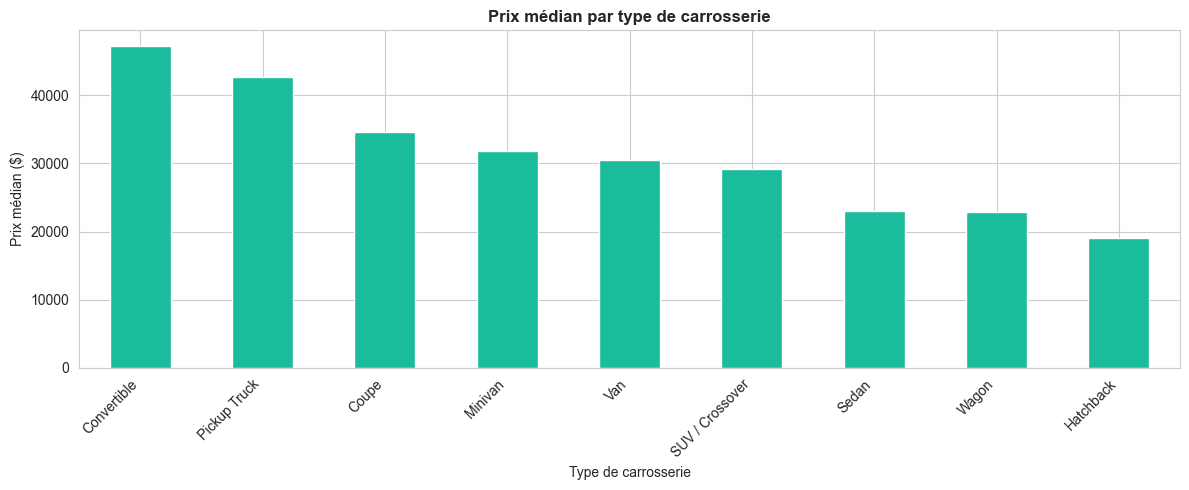

In [ ]:
if 'body_type' in df.columns:
    avg_price = df.groupby('body_type')['price'].median().sort_values(ascending=False)
    avg_price.plot(kind='bar', color='#1abc9c', edgecolor='white', figsize=(12, 5))
    plt.title('Prix médian par type de carrosserie', fontweight='bold')
    plt.xlabel('Type de carrosserie')
    plt.ylabel('Prix médian ($)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Le graphique montre que les convertibles et les pickup trucks ont les prix médians les plus élevés, tandis que les hatchbacks et les wagons présentent les prix médians les plus faibles.
Cela suggère que le type de carrosserie influence fortement le niveau de prix des véhicules.

## 5. Feature Engineering

### 5.1 Âge du véhicule

On a créé une nouvelle variable vehicle_age représentant l’âge du véhicule, calculé comme la différence entre l’année actuelle et l’année de fabrication (year).

In [ ]:
if 'year' in df.columns:
    current_year = pd.Timestamp.now().year
    df['vehicle_age'] = current_year - df['year']
    print(' vehicle_age créé')
    df[['year', 'vehicle_age']].head(3)

 vehicle_age créé


### 5.2 Rapport prix / kilométrage

On a créé une nouvelle variable price_per_mile qui mesure le prix du véhicule par mile parcouru, en divisant le prix par le kilométrage (avec +1 pour éviter une division par zéro).

In [ ]:
if 'price' in df.columns and 'mileage' in df.columns:
    df['price_per_mile'] = df['price'] / (df['mileage'] + 1)  # +1 pour éviter division par 0
    print(' price_per_mile créé')
    df[['price', 'mileage', 'price_per_mile']].head(3)

 price_per_mile créé


### 5.3 Nombre d'options

On a créé une nouvelle variable nb_options qui compte le nombre d’options majeures d’un véhicule en extrayant et en comptant les éléments présents dans la variable major_options.

In [ ]:
if 'major_options' in df.columns:
    df['nb_options'] = df['major_options'].apply(
        lambda x: len(re.findall(r"'", str(x))) // 2 if pd.notna(x) else 0
    )
    print(' nb_options créé')
    df[['major_options', 'nb_options']].head(3)

 nb_options créé


### 5.4 Indicateur véhicule neuf / occasion

On a converti la variable is_new en variable binaire (0/1) afin de la rendre exploitable dans les analyses et modèles. Savoir si le vehicule est neuf ou pas. 

In [ ]:
if 'is_new' in df.columns:
    df['is_new'] = df['is_new'].astype(int)
    print(' is_new converti en entier (0/1)')
    df['is_new'].value_counts()

 is_new converti en entier (0/1)


## 6. Preprocessing

### 6.1 Suppression des colonnes inutiles

In [ ]:
# Colonnes à forte cardinalité ou sans valeur prédictive directe
cols_to_remove = ['vin', 'listing_id', 'sp_name', 'trimId', 'trim_name',
                  'power', 'torque', 'listed_date', 'major_options',
                  'transmission_display', 'wheel_system_display', 'franchise_make']

cols_to_remove = [c for c in cols_to_remove if c in df.columns]
df = df.drop(columns=cols_to_remove)

print(f' Colonnes supprimées : {cols_to_remove}')
print(f'Dimensions : {df.shape}')

 Colonnes supprimées : ['vin', 'listing_id', 'sp_name', 'trimId', 'trim_name', 'power', 'torque', 'listed_date', 'major_options', 'transmission_display', 'wheel_system_display', 'franchise_make']
Dimensions : (1814309, 39)


### 6.2 Encodage des variables catégorielles

In [ ]:
# Séparer colonnes catégorielles à faible/haute cardinalité
cat_cols_final = df.select_dtypes(include=['object', 'category']).columns.tolist()

low_card  = [c for c in cat_cols_final if df[c].nunique() <= 10]
high_card = [c for c in cat_cols_final if df[c].nunique() > 10]

print(f'Faible cardinalité (One-Hot) : {low_card}')
print(f'Haute cardinalité (Label Encoding) : {high_card}')

# One-Hot Encoding pour faible cardinalité
df = pd.get_dummies(df, columns=low_card, drop_first=True)

# Label Encoding pour haute cardinalité
le = LabelEncoder()
for col in high_card:
    df[col] = le.fit_transform(df[col].astype(str))

print(f'\n Encodage terminé. Dimensions : {df.shape}')

Faible cardinalité (One-Hot) : ['body_type', 'fleet', 'fuel_type', 'is_oemcpo', 'transmission', 'wheel_system']
Haute cardinalité (Label Encoding) : ['bed_length', 'engine_cylinders', 'engine_type', 'listing_color', 'make_name', 'maximum_seating', 'model_name']

 Encodage terminé. Dimensions : (1814309, 56)


### 6.3 Normalisation des variables numériques

In [ ]:
# Colonnes numériques à normaliser (hors cible)
target = 'price'
num_cols_final = df.select_dtypes(include='number').columns.tolist()
num_cols_to_scale = [c for c in num_cols_final if c != target]

scaler = StandardScaler()
df[num_cols_to_scale] = scaler.fit_transform(df[num_cols_to_scale])

print(f' Normalisation (StandardScaler) appliquée sur {len(num_cols_to_scale)} colonnes')
df.head(3)

 Normalisation (StandardScaler) appliquée sur 31 colonnes


,back_legroom,bed_length,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,engine_type,franchise_dealer,front_legroom,fuel_tank_volume,height,highway_fuel_economy,horsepower,is_new,length,listing_color,make_name,maximum_seating,mileage,model_name,price,wheelbase,width,year,horsepower_val,torque_val,listed_month,listed_year,listed_dayofweek,vehicle_age,price_per_mile,nb_options,body_type_Coupe,body_type_Hatchback,body_type_Minivan,body_type_Pickup Truck,body_type_SUV / Crossover,body_type_Sedan,body_type_Van,body_type_Wagon,fleet_True,fuel_type_Compressed Natural Gas,fuel_type_Diesel,fuel_type_Electric,fuel_type_Flex Fuel Vehicle,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Propane,transmission_CVT,transmission_Dual Clutch,transmission_M,wheel_system_4X2,wheel_system_AWD,wheel_system_FWD,wheel_system_RWD
0,-0.014048,0.369184,NaN,NaN,1.520827,-0.785529,-0.649610,-0.785529,True,-2.061234,-0.106092,0.271037,NaN,-0.002843,0.739206,-0.599490,-1.397119,0.295105,0.922613,-0.518643,-0.705038,46500.0,-0.498845,0.895158,0.359378,-0.043073,0.050271,-2.229662,0.263933,0.944385,-0.359378,-0.163281,-1.347664,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
1,-0.180071,0.369184,NaN,NaN,1.392348,0.802772,0.118586,0.802772,True,-2.127782,0.989375,0.947382,NaN,1.031912,0.739206,0.099638,-0.628432,0.295105,0.922613,-0.518540,-0.707918,67430.0,-0.005857,1.126755,0.359378,0.991567,0.584908,-2.229662,0.263933,-0.886004,-0.359378,-0.129570,-1.613537,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
2,-0.014048,0.369184,NaN,NaN,0.703232,-0.785529,-0.649610,-0.785529,True,-2.061234,-0.106092,0.271037,NaN,-0.002843,0.739206,-0.599490,-1.397119,0.295105,0.922613,-0.518678,-0.705038,48880.0,-0.498845,0.895158,0.359378,-0.043073,0.050271,-1.358209,0.263933,0.944385,-0.359378,-0.093003,-1.347664,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False


### 6.4 Dataset final

In [ ]:
print('='*50)
print(' DATASET FINAL PRÊT')
print('='*50)
print(f'Dimensions     : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Valeurs manq.  : {df.isna().sum().sum()}')
print(f'Types          : {dict(df.dtypes.value_counts())}')
print()
df.head()

 DATASET FINAL PRÊT
Dimensions     : 1,814,309 lignes × 56 colonnes
Valeurs manq.  : 4136333
Types          : {dtype('float64'): np.int64(32), dtype('bool'): np.int64(24)}



,back_legroom,bed_length,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,engine_type,franchise_dealer,front_legroom,fuel_tank_volume,height,highway_fuel_economy,horsepower,is_new,length,listing_color,make_name,maximum_seating,mileage,model_name,price,wheelbase,width,year,horsepower_val,torque_val,listed_month,listed_year,listed_dayofweek,vehicle_age,price_per_mile,nb_options,body_type_Coupe,body_type_Hatchback,body_type_Minivan,body_type_Pickup Truck,body_type_SUV / Crossover,body_type_Sedan,body_type_Van,body_type_Wagon,fleet_True,fuel_type_Compressed Natural Gas,fuel_type_Diesel,fuel_type_Electric,fuel_type_Flex Fuel Vehicle,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Propane,transmission_CVT,transmission_Dual Clutch,transmission_M,wheel_system_4X2,wheel_system_AWD,wheel_system_FWD,wheel_system_RWD
0,-0.014048,0.369184,NaN,NaN,1.520827,-0.785529,-0.649610,-0.785529,True,-2.061234,-0.106092,0.271037,NaN,-0.002843,0.739206,-0.599490,-1.397119,0.295105,0.922613,-0.518643,-0.705038,46500.0,-0.498845,0.895158,0.359378,-0.043073,0.050271,-2.229662,0.263933,0.944385,-0.359378,-0.163281,-1.347664,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
1,-0.180071,0.369184,NaN,NaN,1.392348,0.802772,0.118586,0.802772,True,-2.127782,0.989375,0.947382,NaN,1.031912,0.739206,0.099638,-0.628432,0.295105,0.922613,-0.518540,-0.707918,67430.0,-0.005857,1.126755,0.359378,0.991567,0.584908,-2.229662,0.263933,-0.886004,-0.359378,-0.129570,-1.613537,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
2,-0.014048,0.369184,NaN,NaN,0.703232,-0.785529,-0.649610,-0.785529,True,-2.061234,-0.106092,0.271037,NaN,-0.002843,0.739206,-0.599490,-1.397119,0.295105,0.922613,-0.518678,-0.705038,48880.0,-0.498845,0.895158,0.359378,-0.043073,0.050271,-1.358209,0.263933,0.944385,-0.359378,-0.093003,-1.347664,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
3,-0.346094,0.369184,NaN,NaN,1.929624,-0.785529,-0.649610,-0.785529,True,-1.329207,-0.313852,0.041079,NaN,0.008165,0.739206,-0.207780,0.908943,0.295105,-0.456882,-0.518506,0.864543,66903.0,-0.137783,0.740760,0.359378,-0.032066,0.050271,-2.665389,0.263933,0.944385,-0.359378,-0.164792,0.513451,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
4,-0.346094,0.369184,NaN,NaN,-0.079323,-0.785529,-0.649610,-0.785529,True,-1.329207,-0.313852,0.041079,NaN,0.008165,0.739206,-0.207780,1.101115,0.295105,-0.456882,-0.518540,0.864543,68520.0,-0.137783,0.740760,0.359378,-0.032066,0.050271,-0.051029,0.263933,-0.886004,-0.359378,-0.122802,-1.347664,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
